<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

I0000 00:00:1786703614.037258    6200 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786703615.059275    6200 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786703617.425201    6200 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Datos
Se usa como corpus la novela **"La metamorfosis"** de Franz Kafka (`laMetamorfosis.txt`). El archivo debe estar disponible en el mismo directorio que este notebook.

In [2]:
# Lectura del corpus local
with open('laMetamorfosis.txt', 'r', encoding='utf-8') as f:
    article_text = f.read()

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [3]:
# en article_text se encuentra el texto de todo el libro
article_text[:1000]

'i\n\ncuando gregorio samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto. estaba tumbado sobre su espalda dura, y en forma de caparazón y, al levantar un poco la cabeza veía un vientre abombado, parduzco, dividido por partes duras en forma de arco, sobre cuya protuberancia apenas podía mantenerse el cobertor, a punto ya de resbalar al suelo. sus muchas patas, ridículamente pequeñas en comparación con el resto de su tamaño, le vibraban desamparadas ante los ojos.\n\n«¿qué me ha ocurrido?», pensó.\n\nno era un sueño. su habitación, una auténtica habitación humana, si bien algo pequeña, permanecía tranquila entre las cuatro paredes harto conocidas. por encima de la mesa, sobre la que se encontraba extendido un muestrario de paños desempaquetados —samsa era viajante de comercio—, estaba colgado aquel cuadro que hacía poco había recortado de una revista y había colocado en un bonito marco dorado. representaba a una dam

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [4]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [5]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [6]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [7]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

47

In [8]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [9]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [10]:
tokenized_text[:1000]

[31,
 0,
 0,
 27,
 5,
 19,
 16,
 37,
 43,
 42,
 1,
 34,
 35,
 1,
 43,
 34,
 31,
 43,
 42,
 6,
 19,
 7,
 6,
 19,
 42,
 6,
 35,
 42,
 37,
 35,
 6,
 28,
 35,
 34,
 20,
 12,
 42,
 5,
 16,
 19,
 42,
 7,
 19,
 25,
 19,
 16,
 19,
 42,
 37,
 35,
 6,
 28,
 5,
 36,
 6,
 42,
 37,
 35,
 42,
 5,
 16,
 42,
 6,
 5,
 35,
 25,
 43,
 42,
 31,
 16,
 20,
 34,
 19,
 16,
 38,
 5,
 31,
 10,
 43,
 15,
 42,
 6,
 35,
 42,
 35,
 16,
 27,
 43,
 16,
 20,
 34,
 12,
 42,
 6,
 43,
 39,
 34,
 35,
 42,
 6,
 5,
 42,
 27,
 19,
 7,
 19,
 42,
 27,
 43,
 16,
 30,
 35,
 34,
 20,
 31,
 37,
 43,
 42,
 35,
 16,
 42,
 5,
 16,
 42,
 7,
 43,
 16,
 6,
 20,
 34,
 5,
 43,
 6,
 43,
 42,
 31,
 16,
 6,
 35,
 27,
 20,
 43,
 45,
 42,
 35,
 6,
 20,
 19,
 39,
 19,
 42,
 20,
 5,
 7,
 39,
 19,
 37,
 43,
 42,
 6,
 43,
 39,
 34,
 35,
 42,
 6,
 5,
 42,
 35,
 6,
 28,
 19,
 10,
 37,
 19,
 42,
 37,
 5,
 34,
 19,
 15,
 42,
 18,
 42,
 35,
 16,
 42,
 23,
 43,
 34,
 7,
 19,
 42,
 37,
 35,
 42,
 27,
 19,
 28,
 19,
 34,
 19,
 41,
 12,
 16,
 42,
 18,
 15,

### Organizando y estructurando el dataset

In [11]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [12]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [13]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [14]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [15]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences_train` las subsecuencias de caracteres del corpus. Vamos a quedarnos con un conjunto de validación (`tokenized_sentences_val`) que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [16]:
X.shape

(108776, 100)

In [17]:
X[0,:10]

array([31,  0,  0, 27,  5, 19, 16, 37, 43, 42])

In [18]:
y[0,:10]

array([ 0,  0, 27,  5, 19, 16, 37, 43, 42,  1])

In [19]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [20]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, LSTM as LSTMLayer, GRU, Dense
from keras.models import Model, Sequential

### Arquitecturas propuestas

Al igual que en el ejemplo, el modelo consume los índices de los tokens y los transforma en vectores OHE (no se entrena una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` -que transforma índices a vectores OHE- y `TimeDistributed` -que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

Siguiendo las sugerencias de la consigna, se proponen tres arquitecturas basadas en distintas unidades recurrentes:

- **SimpleRNN (celda de Elman)**: la más simple, sirve como línea de base. Al ser una recurrencia simple sufre el problema del desvanecimiento del gradiente, por lo que le cuesta capturar dependencias de largo plazo (relevante acá porque `max_context_size=100`).
- **LSTM**: incorpora *gates* (entrada, olvido y salida) y un estado de celda que le permite retener información por más pasos temporales, mitigando el desvanecimiento del gradiente. Es más costosa en parámetros y cómputo.
- **GRU**: una simplificación de la LSTM (sólo dos *gates*: actualización y reseteo) que suele lograr un desempeño similar a la LSTM con menos parámetros y entrenamiento más rápido.

Se define una función `build_model` parametrizada por el tipo de celda recurrente para poder instanciar y comparar las tres arquitecturas manteniendo el resto del pipeline (pre-procesamiento, callback de perplejidad, generación) sin cambios.

In [21]:
def build_model(cell_type='lstm', units=200, dropout=0.1, recurrent_dropout=0.1):
    """
        Construye y compila un modelo de lenguaje por caracteres.

        Args:
            cell_type (str): 'simplernn', 'lstm' o 'gru'
            units (int): dimensión del estado oculto de la celda recurrente
            dropout (float): dropout sobre las conexiones de entrada
            recurrent_dropout (float): dropout sobre las conexiones recurrentes
        returns:
            model (keras.Model): modelo compilado
    """
    model = Sequential()
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))

    if cell_type == 'simplernn':
        model.add(SimpleRNN(units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout))
    elif cell_type == 'lstm':
        model.add(LSTMLayer(units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout))
    elif cell_type == 'gru':
        model.add(GRU(units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout))
    else:
        raise ValueError(f"cell_type '{cell_type}' no soportado. Usar 'simplernn', 'lstm' o 'gru'.")

    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

    return model

In [22]:
# comparamos las tres arquitecturas propuestas en términos de cantidad de parámetros
for cell_type in ['simplernn', 'lstm', 'gru']:
    candidate = build_model(cell_type)
    print(f"--- {cell_type} ---")
    candidate.summary()
    print()

--- simplernn ---


/home/lvillal/CEIA/ceia_uv/.venv/lib/python3.13/site-packages/keras/src/layers/core/wrapper.py:25: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1786703620.384248    6200 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 47)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        49,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 47)       │         9,447 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,047 (230.65 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 47)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       149,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 47)       │         9,447 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,847 (620.50 KB)

 Trainable params: 158,847 (620.50 KB)

 Non-trainable params: 0 (0.00 B)

### Selección del modelo a entrenar

Se opta por entrenar la arquitectura **LSTM**: al tener un contexto de 100 caracteres, se busca una celda que module mejor las dependencias de largo plazo que una SimpleRNN, y frente a la GRU se prioriza la mayor capacidad de la LSTM para retener información aun a costa de más parámetros. Queda como ejercicio adicional repetir el entrenamiento con GRU (o SimpleRNN) reutilizando `build_model('gru')` para comparar la perplejidad obtenida.

In [23]:
model = build_model('lstm')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_3              │ (None, None, 47)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 200)      │       198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, None, 47)       │         9,447 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,847 (811.90 KB)

 Trainable params: 207,847 (811.90 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [24]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True

### Entrenamiento

In [25]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - loss: 2.5966
 mean perplexity: 9.415308022499085 

Saved new model!
425/425 ━━━━━━━━━━━━━━━━━━━━ 320s 740ms/step - loss: 2.5966
Epoch 2/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - loss: 2.1304
 mean perplexity: 7.918080151081085 

Saved new model!
425/425 ━━━━━━━━━━━━━━━━━━━━ 297s 700ms/step - loss: 2.1304
Epoch 3/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - loss: 1.9870
 mean perplexity: 7.406383941570918 

Saved new model!
425/425 ━━━━━━━━━━━━━━━━━━━━ 299s 704ms/step - loss: 1.9870
Epoch 4/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - loss: 1.8938
 mean perplexity: 7.052295202016831 

Saved new model!
425/425 ━━━━━━━━━━━━━━━━━━━━ 313s 735ms/step - loss: 1.8938
Epoch 5/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - loss: 1.8270
 mean perplexity: 6.751096081733704 

Saved new model!
425/425 ━━━━━━━━━━━━━━━━━━━━ 293s 690ms/step - loss: 1.8270
Epoch 6/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - loss: 1.7732
 mean perpl

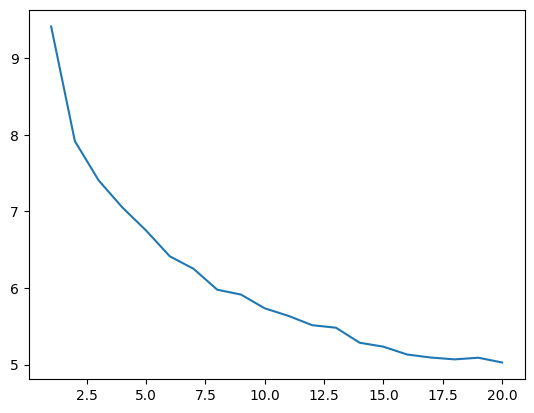

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [27]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [28]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

#!pip install -q gradio

In [29]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

/home/lvillal/CEIA/ceia_uv/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Keyboard interruption in main thread... closing server.


### Generación de secuencias

In [30]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction (greedy search)

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [31]:
input_text = 'gregorio samsa se despertó una mañana'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'gregorio samsa se despertó una mañana y se abrir de la cama y la he'

###  Beam search y muestreo aleatorio

In [32]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [33]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [34]:
# predicción con beam search determinístico
salidas = beam_search(model,num_beams=10,num_words=20,input="gregorio despertó")

In [35]:
salidas[0]

array([ 1, 34, 35,  1, 43, 34, 31, 43, 42, 37, 35,  6, 28, 35, 34, 20, 12,
       42, 37, 35, 42, 10, 19, 42,  4, 19, 39, 31, 20, 19, 27, 31, 12, 16,
       42, 37, 35])

In [36]:
# veamos las salidas
decode(salidas[0])

'gregorio despertó de la habitación de'

### Efecto de la temperatura en el beam search estocástico

En el beam_search estocastico (mode='sto'), en lugar de tomar siempre los num_beams candidatos con mayor probabilidad, se muestrea de una distribución softmax(log-probabilidades / temp). El parámetro temp (temperatura) controla qué tan "aplanada" o "picuda" queda esa distribución:

- **Temperatura baja** (temp < 1): la distribución se vuelve más picuda, el muestreo se parece cada vez más al comportamiento determinístico (elige casi siempre los candidatos más probables) -> texto más conservador, repetitivo y coherente.
- **Temperatura ≈ 1**: se muestrea directamente de la distribución de probabilidades del modelo, sin distorsión.
- **Temperatura alta** (temp > 1): la distribución se aplana, aumentando la probabilidad de elegir candidatos menos probables -> texto más diverso y creativo, pero con mayor riesgo de incoherencia o errores gramaticales.

A continuación comparamos la generación estocástica con distintas temperaturas para un mismo contexto de entrada.

In [39]:
input_seed = "gregorio despertó"

for temp in [0.3, 1.0, 2.0, 4.0]:
    salidas_sto = beam_search(model, num_beams=5, num_words=20, input=input_seed, temp=temp, mode='sto')
    print(f">>>>>>> temperatura = {temp} ---")
    for beam in salidas_sto:
        print(decode(beam))
    print()

>>>>>>> temperatura = 0.3 ---
gregorio despertó de la hermana, por 
gregorio despertó de la hermana, pero
gregorio despertó de la hermana, pero
gregorio despertó de la hermana, pero
gregorio despertó de la hermana, por 

>>>>>>> temperatura = 1.0 ---
gregorio despertó de la madre, que bu
gregorio despertó de la madre, para a
gregorio despertó de la madre, que si
gregorio despertó de la madre, que gr
gregorio despertó de la madre, para v

>>>>>>> temperatura = 2.0 ---
gregorio despertó en la escucla duran
gregorio despertó en la escucla durar
gregorio despertó en la escucada posb
gregorio despertó en la escucada posq
gregorio despertó en la escucla durac

>>>>>>> temperatura = 4.0 ---
gregorio despertón: era isteáca!éle— 
gregorio despertón: era isteáca!éle—n
gregorio despertón: era a vejazó)y) a
gregorio despertón: era a vejazó)y) u
gregorio despertón: era a vejazó)y) «



Se espera observar que, a medida que la temperatura aumenta, las secuencias generadas por los distintos beams se diversifican entre sí y respecto de la opción determinística/greedy, a costa de una mayor probabilidad de generar combinaciones de caracteres poco frecuentes o gramaticalmente inconsistentes. Con temperaturas bajas, en cambio, el muestreo estocástico tiende a converger a la misma secuencia que produce el beam search determinístico.